# Day 9 - Teaching AI Semantic Meaning Through Vectors

## Semantic Similarity Using TF-IDF and Cosine Similarity

Computers cannot directly understand plain text in the same way humans do.
Words and sentences must be converted into numerical representations before
machine learning algorithms can process and compare them.

In this project, we use TF-IDF (Term Frequency-Inverse Document Frequency)
to convert sentences into numerical vectors. TF-IDF gives more importance
to words that are useful for distinguishing between documents.

After converting text into vectors, cosine similarity is used to measure
how similar two sentences are. A higher cosine similarity score means that
the vectors point in more similar directions, while a score close to zero
means that the texts have little overlap.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 10 sentences covering 3 distinct topics

corpus = [
    # Animals
    "The dog is playing in the garden.",
    "A puppy is running with the dog.",
    "Dogs and puppies are friendly animals.",
    "The cat is sleeping near the window.",

    # Technology
    "Artificial intelligence is changing modern technology.",
    "Machine learning helps computers learn from data.",
    "Python is a popular programming language for AI.",
    
    # Travel
    "The airplane is flying to another city.",
    "Travelers are waiting at the airport.",
    "The train is a convenient way to travel."
]

print("Number of sentences:", len(corpus))

for i, sentence in enumerate(corpus, start=1):
    print(f"{i}. {sentence}")

Number of sentences: 10
1. The dog is playing in the garden.
2. A puppy is running with the dog.
3. Dogs and puppies are friendly animals.
4. The cat is sleeping near the window.
5. Artificial intelligence is changing modern technology.
6. Machine learning helps computers learn from data.
7. Python is a popular programming language for AI.
8. The airplane is flying to another city.
9. Travelers are waiting at the airport.
10. The train is a convenient way to travel.


In [3]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Convert the corpus into TF-IDF vectors
tfidf_matrix = vectorizer.fit_transform(corpus)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (10, 50)


In [4]:
# Display the vocabulary/features learned by TF-IDF

features = vectorizer.get_feature_names_out()

print("Number of features:", len(features))
print("\nFirst 20 features:")
print(features[:20])

Number of features: 50

First 20 features:
['ai' 'airplane' 'airport' 'and' 'animals' 'another' 'are' 'artificial'
 'at' 'cat' 'changing' 'city' 'computers' 'convenient' 'data' 'dog' 'dogs'
 'flying' 'for' 'friendly']


In [5]:
# Display the vocabulary/features learned by TF-IDF

features = vectorizer.get_feature_names_out()

print("Number of features:", len(features))
print("\nFirst 20 features:")
print(features[:20])

Number of features: 50

First 20 features:
['ai' 'airplane' 'airport' 'and' 'animals' 'another' 'are' 'artificial'
 'at' 'cat' 'changing' 'city' 'computers' 'convenient' 'data' 'dog' 'dogs'
 'flying' 'for' 'friendly']


In [6]:
# Calculate pairwise cosine similarity

similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", similarity_matrix.shape)
print("\nCosine Similarity Matrix:")
print(np.round(similarity_matrix, 2))

Similarity matrix shape: (10, 10)

Cosine Similarity Matrix:
[[1.   0.33 0.   0.26 0.05 0.   0.04 0.16 0.11 0.16]
 [0.33 1.   0.   0.17 0.05 0.   0.05 0.11 0.06 0.11]
 [0.   0.   1.   0.   0.   0.   0.   0.   0.13 0.  ]
 [0.26 0.17 0.   1.   0.04 0.   0.04 0.15 0.11 0.15]
 [0.05 0.05 0.   0.04 1.   0.   0.04 0.05 0.   0.05]
 [0.   0.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.04 0.05 0.   0.04 0.04 0.   1.   0.04 0.   0.04]
 [0.16 0.11 0.   0.15 0.05 0.   0.04 1.   0.06 0.24]
 [0.11 0.06 0.13 0.11 0.   0.   0.   0.06 1.   0.06]
 [0.16 0.11 0.   0.15 0.05 0.   0.04 0.24 0.06 1.  ]]


In [7]:
def find_similar(query, corpus, top_k=3):
    """
    Find the most similar sentences in the corpus
    using TF-IDF and cosine similarity.
    """

    # Create a vectorizer and fit it on the corpus
    vectorizer = TfidfVectorizer()
    corpus_vectors = vectorizer.fit_transform(corpus)

    # Convert the query into the same TF-IDF vector space
    query_vector = vectorizer.transform([query])

    # Calculate similarity between query and every corpus sentence
    scores = cosine_similarity(query_vector, corpus_vectors)[0]

    # Get indices of the highest similarity scores
    top_indices = np.argsort(scores)[::-1][:top_k]

    # Return sentences with their scores
    results = []

    for index in top_indices:
        results.append((corpus[index], scores[index]))

    return results

In [8]:
query = "A small puppy is playing with a dog."

results = find_similar(query, corpus, top_k=3)

print("Query:", query)
print("\nMost similar sentences:")

for sentence, score in results:
    print(f"{score:.4f}  →  {sentence}")

Query: A small puppy is playing with a dog.

Most similar sentences:
0.7217  →  A puppy is running with the dog.
0.4356  →  The dog is playing in the garden.
0.0522  →  Artificial intelligence is changing modern technology.


In [10]:
test_pairs = [
    ("dog", "puppy"),
    ("dog", "airplane"),
    ("machine learning", "artificial intelligence"),
    ("airport", "airplane"),
    ("cat", "python programming")
]

print("Pairwise Similarity Tests:\n")

for text1, text2 in test_pairs:
    pair_vectorizer = TfidfVectorizer()

    vectors = pair_vectorizer.fit_transform([text1, text2])

    score = cosine_similarity(vectors[0:1], vectors[1:2])[0][0]

    print(f"{text1!r} vs {text2!r} = {score:.4f}")

Pairwise Similarity Tests:

'dog' vs 'puppy' = 0.0000
'dog' vs 'airplane' = 0.0000
'machine learning' vs 'artificial intelligence' = 0.0000
'airport' vs 'airplane' = 0.0000
'cat' vs 'python programming' = 0.0000


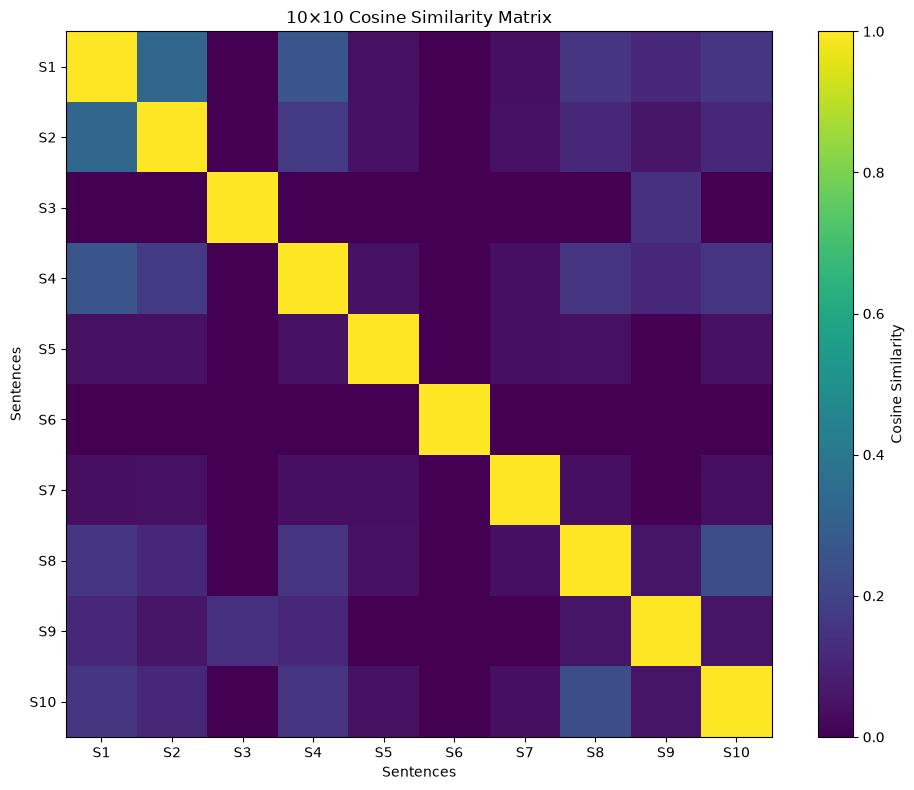

In [11]:
# Create labels for the 10 sentences
labels = [f"S{i}" for i in range(1, 11)]

# Create the heatmap
plt.figure(figsize=(10, 8))

plt.imshow(similarity_matrix, cmap="viridis", interpolation="nearest")

# Add color bar
plt.colorbar(label="Cosine Similarity")

# Label the axes
plt.xticks(range(10), labels)
plt.yticks(range(10), labels)

plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.title("10×10 Cosine Similarity Matrix")

plt.tight_layout()
plt.show()

## Understanding Cosine Similarity

Cosine similarity measures the similarity between two vectors by calculating
the cosine of the angle between them.

The formula is:

cosine_similarity(A, B) = (A · B) / (||A|| × ||B||)

Where:

- A · B is the dot product of the two vectors.
- ||A|| is the magnitude (length) of vector A.
- ||B|| is the magnitude (length) of vector B.

The resulting score normally ranges from 0 to 1 for TF-IDF vectors:

- 1.0 → the vectors point in exactly the same direction.
- 0.0 → the vectors have no overlap in their represented features.
- Higher score → greater similarity between the texts.

### Why measure the angle instead of distance?

Cosine similarity focuses on the direction of a vector rather than its
magnitude. This is useful for text because two documents can contain very
different amounts of text but still discuss similar content.

For example, a short document and a much longer document may contain similar
important words. Their vector lengths can be different, but their directions
can still be similar.

Euclidean distance would be strongly affected by the size or length of the
vectors. Cosine similarity reduces this problem by normalizing the vectors
and focusing on their orientation.

Therefore, cosine similarity is useful for comparing text represented as
TF-IDF vectors because it focuses more on the pattern of important words
than on the absolute amount of text.